# Readout Frequency Optimization
Load `ds_raw.h5` from a readout-frequency-optimization measurement (IQ vs frequency for two prepared states) and fit the resonant frequency for each state.

In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from scqat.parsers.xarray_h5_parser import load_xarray_h5
from scqat.parsers.qualibrate_parser import repetition_data
from scqat.math_tools import get_fitter

## 1. Configuration

In [2]:
DATA_FOLDER = r"D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q1\ng01_ref0165_test04\#9_08a_readout_frequency_optimization_015851"
DS_RAW_PATH = os.path.join(DATA_FOLDER, "ds_raw.h5")

## 2. Load Dataset

In [3]:
dataset = load_xarray_h5(DS_RAW_PATH)
sq_data = repetition_data(dataset)[0]
sq_data

<xarray.Dataset> Size: 4kB
Dimensions:            (detuning: 50)
Coordinates:
  * detuning           (detuning) float64 400B -5e+05 -4.8e+05 ... 4.8e+05
    full_freq          (detuning) float64 400B 4.912e+09 4.912e+09 ... 4.913e+09
    qubit              <U2 8B 'q1'
Data variables:
    I_g                (detuning) float64 400B 0.001968 0.001819 ... -0.001691
    Q_g                (detuning) float64 400B -0.002184 -0.002311 ... -0.001862
    I_e                (detuning) float64 400B 0.001667 0.001533 ... -0.001983
    Q_e                (detuning) float64 400B -0.002281 -0.002356 ... -0.00182
    D                  (detuning) float64 400B 0.0003154 0.0002891 ... 0.0002951
    IQ_abs_g           (detuning) float64 400B 0.00294 0.002941 ... 0.002515
    IQ_abs_e           (detuning) float64 400B 0.002826 0.002811 ... 0.002691
    optimal_index      int32 4B 28
    optimal_detuning   float64 8B 6e+04
    optimal_frequency  float64 8B 4.912e+09
    chi                float64 8B -7e+04

## 3. Inspect Format

In [4]:
print("Data variables:", list(sq_data.data_vars))
print("Coordinates:   ", list(sq_data.coords))
print("Dims:          ", dict(sq_data.sizes))
print("Attrs:         ", dict(sq_data.attrs))

Data variables: ['I_g', 'Q_g', 'I_e', 'Q_e', 'D', 'IQ_abs_g', 'IQ_abs_e', 'optimal_index', 'optimal_detuning', 'optimal_frequency', 'chi']
Coordinates:    ['detuning', 'full_freq', 'qubit']
Dims:           {'detuning': 50}
Attrs:          {}


## 4. Build |IQ| Traces vs Frequency
Compute magnitudes from `(I_g, Q_g)` and `(I_e, Q_e)` along `detuning`. Use the `full_freq` coordinate (RF frequency) on the x-axis.

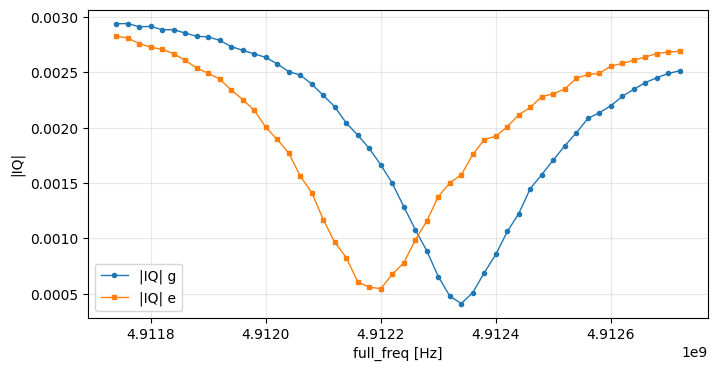

In [5]:
mag_g = np.sqrt(sq_data["I_g"] ** 2 + sq_data["Q_g"] ** 2)
mag_e = np.sqrt(sq_data["I_e"] ** 2 + sq_data["Q_e"] ** 2)

freq = sq_data.coords["full_freq"].values
if freq.ndim != 1 or freq.size != mag_g.sizes["detuning"]:
    raise ValueError(f"Unexpected full_freq shape: {freq.shape}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(freq, mag_g.values, "o-", lw=1, ms=3, label="|IQ| g")
ax.plot(freq, mag_e.values, "s-", lw=1, ms=3, label="|IQ| e")
ax.set_xlabel("full_freq [Hz]")
ax.set_ylabel("|IQ|")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## 5. Fit Lorentzian to Find Resonant Frequencies
Fit each magnitude trace with a Lorentzian. Readout-resonator response is typically a dip in `|IQ|`, so we use `inverted=True`. The fitted `x0` is the resonant frequency. Set `INVERTED = False` if your data shows a peak instead.

In [6]:
INVERTED = True  # set False if |IQ| shows a peak instead of a dip

def fit_resonance(mag, freq, label, inverted=INVERTED):
    da = xr.DataArray(mag.values, coords={"x": freq}, dims="x")
    fitter = get_fitter("lorentzian", da, inverted=inverted)
    fitter.guess()
    result = fitter.fit()
    f0 = result.params["x0"].value
    f0_err = result.params["x0"].stderr
    fwhm = 2 * result.params["gamma"].value
    print(f"[{label}] f0 = {f0:.6e} Hz   (stderr = {f0_err}),  FWHM = {fwhm:.3e} Hz")
    return result, f0

res_g, f0_g = fit_resonance(mag_g, freq, "ground")
res_e, f0_e = fit_resonance(mag_e, freq, "excited")

print(f"\nf0_e - f0_g = {(f0_e - f0_g):.3e} Hz")

[ground] f0 = 4.912346e+09 Hz   (stderr = 1780.464739146822),  FWHM = 3.358e+05 Hz
[excited] f0 = 4.912199e+09 Hz   (stderr = 2291.6569980379377),  FWHM = 3.263e+05 Hz

f0_e - f0_g = -1.472e+05 Hz


## 6. Plot Fits

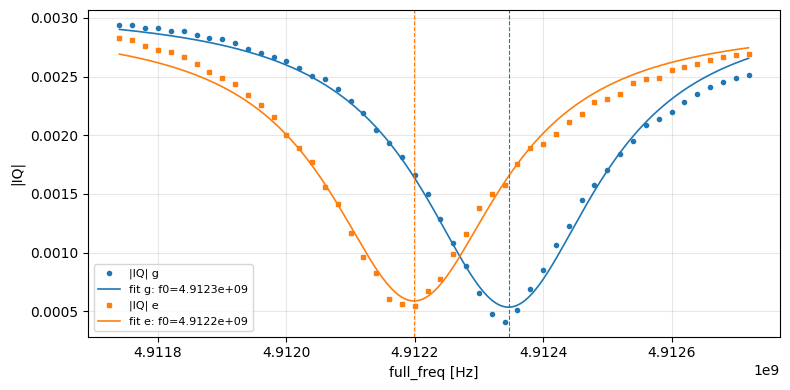

In [7]:
freq_dense = np.linspace(freq.min(), freq.max(), 500)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(freq, mag_g.values, "o", ms=3, color="C0", label="|IQ| g")
ax.plot(freq_dense, res_g.eval(x=freq_dense), "-", color="C0", lw=1.2, label=f"fit g: f0={f0_g:.4e}")
ax.plot(freq, mag_e.values, "s", ms=3, color="C1", label="|IQ| e")
ax.plot(freq_dense, res_e.eval(x=freq_dense), "-", color="C1", lw=1.2, label=f"fit e: f0={f0_e:.4e}")
ax.axvline(f0_g, color="C0", ls="--", lw=0.8)
ax.axvline(f0_e, color="C1", ls="--", lw=0.8)
ax.set_xlabel("full_freq [Hz]")
ax.set_ylabel("|IQ|")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Readout Frequency Optimization
Load `ds_raw.h5` from a readout-frequency-optimization measurement (IQ vs frequency for two prepared states) and inspect its format before fitting the resonant frequency.

In [8]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from scqat.parsers.xarray_h5_parser import load_xarray_h5
from scqat.parsers.qualibrate_parser import repetition_data

## 1. Configuration

In [9]:
DATA_FOLDER = r"D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q1\ng01_ref0165_test04\#9_08a_readout_frequency_optimization_015851"
DS_RAW_PATH = os.path.join(DATA_FOLDER, "ds_raw.h5")

## 2. Load Dataset

In [10]:
dataset = load_xarray_h5(DS_RAW_PATH)
dataset

<xarray.Dataset> Size: 4kB
Dimensions:            (detuning: 50, qubit: 1)
Coordinates:
  * detuning           (detuning) float64 400B -5e+05 -4.8e+05 ... 4.8e+05
    full_freq          (qubit, detuning) float64 400B 4.912e+09 ... 4.913e+09
  * qubit              (qubit) object 8B 'q1'
Data variables:
    I_g                (qubit, detuning) float64 400B 0.001968 ... -0.001691
    Q_g                (qubit, detuning) float64 400B -0.002184 ... -0.001862
    I_e                (qubit, detuning) float64 400B 0.001667 ... -0.001983
    Q_e                (qubit, detuning) float64 400B -0.002281 ... -0.00182
    D                  (qubit, detuning) float64 400B 0.0003154 ... 0.0002951
    IQ_abs_g           (qubit, detuning) float64 400B 0.00294 ... 0.002515
    IQ_abs_e           (qubit, detuning) float64 400B 0.002826 ... 0.002691
    optimal_index      (qubit) int32 4B 28
    optimal_detuning   (qubit) float64 8B 6e+04
    optimal_frequency  (qubit) float64 8B 4.912e+09
    chi                (qubit) float64 8B -7e+04

In [11]:
# Split along the repetition (qubit) dimension and take the first entry
sq_data = repetition_data(dataset)[0]
sq_data

<xarray.Dataset> Size: 4kB
Dimensions:            (detuning: 50)
Coordinates:
  * detuning           (detuning) float64 400B -5e+05 -4.8e+05 ... 4.8e+05
    full_freq          (detuning) float64 400B 4.912e+09 4.912e+09 ... 4.913e+09
    qubit              <U2 8B 'q1'
Data variables:
    I_g                (detuning) float64 400B 0.001968 0.001819 ... -0.001691
    Q_g                (detuning) float64 400B -0.002184 -0.002311 ... -0.001862
    I_e                (detuning) float64 400B 0.001667 0.001533 ... -0.001983
    Q_e                (detuning) float64 400B -0.002281 -0.002356 ... -0.00182
    D                  (detuning) float64 400B 0.0003154 0.0002891 ... 0.0002951
    IQ_abs_g           (detuning) float64 400B 0.00294 0.002941 ... 0.002515
    IQ_abs_e           (detuning) float64 400B 0.002826 0.002811 ... 0.002691
    optimal_index      int32 4B 28
    optimal_detuning   float64 8B 6e+04
    optimal_frequency  float64 8B 4.912e+09
    chi                float64 8B -7e+04

## 3. Inspect Variables / Coordinates / Attributes

In [12]:
print("Data variables:", list(sq_data.data_vars))
print("Coordinates:   ", list(sq_data.coords))
print("Dims:          ", dict(sq_data.sizes))
print("Attrs:         ", dict(sq_data.attrs))

Data variables: ['I_g', 'Q_g', 'I_e', 'Q_e', 'D', 'IQ_abs_g', 'IQ_abs_e', 'optimal_index', 'optimal_detuning', 'optimal_frequency', 'chi']
Coordinates:    ['detuning', 'full_freq', 'qubit']
Dims:           {'detuning': 50}
Attrs:          {}


In [13]:
# Detailed view of each data variable
for name, var in sq_data.data_vars.items():
    print(f"--- {name} ---")
    print("  dims :", var.dims)
    print("  shape:", var.shape)
    print("  dtype:", var.dtype)
    print("  attrs:", dict(var.attrs))

for name, coord in sq_data.coords.items():
    print(f"=== coord: {name} ===")
    print("  dims :", coord.dims)
    print("  shape:", coord.shape)
    print("  dtype:", coord.dtype)
    print("  attrs:", dict(coord.attrs))

--- I_g ---
  dims : ('detuning',)
  shape: (50,)
  dtype: float64
  attrs: {}
--- Q_g ---
  dims : ('detuning',)
  shape: (50,)
  dtype: float64
  attrs: {}
--- I_e ---
  dims : ('detuning',)
  shape: (50,)
  dtype: float64
  attrs: {}
--- Q_e ---
  dims : ('detuning',)
  shape: (50,)
  dtype: float64
  attrs: {}
--- D ---
  dims : ('detuning',)
  shape: (50,)
  dtype: float64
  attrs: {}
--- IQ_abs_g ---
  dims : ('detuning',)
  shape: (50,)
  dtype: float64
  attrs: {}
--- IQ_abs_e ---
  dims : ('detuning',)
  shape: (50,)
  dtype: float64
  attrs: {}
--- optimal_index ---
  dims : ()
  shape: ()
  dtype: int32
  attrs: {}
--- optimal_detuning ---
  dims : ()
  shape: ()
  dtype: float64
  attrs: {'long_name': 'readout frequency', 'units': 'Hz'}
--- optimal_frequency ---
  dims : ()
  shape: ()
  dtype: float64
  attrs: {'long_name': 'Readout RF frequency', 'units': 'Hz'}
--- chi ---
  dims : ()
  shape: ()
  dtype: float64
  attrs: {}
=== coord: detuning ===
  dims : ('detuning',)
